<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> DGM </b><br><br>HW3_Q2</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


## Q1-part2-subdivision1
---

In [14]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ==========================================
# Configuration Class
# ==========================================
class NCSNConfig:
    """
    Configuration class to hold hyperparameters for the NCSN model and training.
    """
    def __init__(self):
        # Data Parameters
        self.dataset_name = 'MNIST'
        self.image_size = 28
        self.channels = 1
        self.batch_size = 64
        self.num_workers = 2

        # Noise (Sigma) Parameters
        self.sigma_begin = 30.0  # Starting noise level (high variance)
        self.sigma_end = 0.01    # Ending noise level (low variance)
        self.num_classes = 50    # Number of noise levels (L)

        # Device
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_sigmas(config):
    """
    Generates a geometric sequence of sigma values (noise levels).
    Formula: geometric progression from sigma_begin to sigma_end.
    """
    sigmas = torch.tensor(
        np.exp(np.linspace(np.log(config.sigma_begin), np.log(config.sigma_end), config.num_classes))
    ).float().to(config.device)

    return sigmas

def get_dataloader(config):
    """
    Downloads and prepares the MNIST dataloader.
    Normalization: Transforms [0, 1] images to [-1, 1].
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)) # Map to [-1, 1]
    ])

    dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
    loader = DataLoader(
        dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers
    )
    return loader

# ==========================================
# Execution (Run this in Colab Cell)
# ==========================================
config = NCSNConfig()
sigmas = get_sigmas(config)
train_loader = get_dataloader(config)

print(f"--- Setup Complete ---")
print(f"Device: {config.device}")
print(f"Sigma Sequence ({len(sigmas)} levels): \n{sigmas.cpu().numpy()}")
print(f"Batch Size: {config.batch_size}")

--- Setup Complete ---
Device: cuda
Sigma Sequence (50 levels): 
[3.00000000e+01 2.54776630e+01 2.16370449e+01 1.83753777e+01
 1.56053896e+01 1.32529621e+01 1.12551508e+01 9.55849743e+00
 8.11760616e+00 6.89392138e+00 5.85470057e+00 4.97213602e+00
 4.22261381e+00 3.58607769e+00 3.04549599e+00 2.58640409e+00
 2.19651771e+00 1.86540473e+00 1.58420515e+00 1.34539485e+00
 1.14258385e+00 9.70345557e-01 8.24071288e-01 6.99847043e-01
 5.94348907e-01 5.04754007e-01 4.28665102e-01 3.64046186e-01
 3.09168190e-01 2.62562782e-01 2.22982869e-01 1.89369425e-01
 1.60823017e-01 1.36579812e-01 1.15991153e-01 9.85061228e-02
 8.36568624e-02 7.10460469e-02 6.03362396e-02 5.12408800e-02
 4.35165986e-02 3.69567052e-02 3.13856862e-02 2.66544633e-02
 2.26364490e-02 1.92241278e-02 1.63261946e-02 1.38651095e-02
 1.17750205e-02 9.99999978e-03]
Batch Size: 64


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ==========================================
# Layer Modules
# ==========================================

class GaussianFourierEmbedding(nn.Module):
    """
    Embeds scalar noise levels (sigma) into high-dimensional vectors
    using random Gaussian Fourier features.
    Reference: 'Fourier Features Let Networks Learn High Frequency Functions in Low Dimensional Domains'
    """
    def __init__(self, embed_dim=256, scale=30.0):
        super().__init__()
        # Random weight matrix (freqs) fixed during training
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x):
        # x shape: [Batch] -> [Batch, 1]
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        # Concatenate sin and cos features
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class FiLMLayer(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM) Layer.
    Modulates the feature map based on the noise embedding.
    """
    def __init__(self, in_channels, emb_dim):
        super().__init__()
        self.group_norm = nn.GroupNorm(num_groups=32, num_channels=in_channels)
        self.proj = nn.Linear(emb_dim, in_channels * 2) # Outputs both scale (gamma) and shift (beta)

    def forward(self, x, emb):
        # Project embedding to get scale and shift parameters
        stats = self.proj(emb)
        stats = stats[:, :, None, None] # Reshape for broadcasting: [B, 2*C, 1, 1]

        scale, shift = stats.chunk(2, dim=1)

        x = self.group_norm(x)
        # Apply affine transformation (Note: (1 + scale) for stability)
        x = x * (1 + scale) + shift
        return x


class FiLMResBlock(nn.Module):
    """
    Residual Block enhanced with FiLM layers for conditioning.
    Structure: Conv -> FiLM -> Act -> Conv -> FiLM -> Act -> Add Residual
    """
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.film1 = FiLMLayer(out_channels, emb_dim)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.film2 = FiLMLayer(out_channels, emb_dim)

        self.activation = nn.SiLU() # Swish activation

        # Shortcut connection handling (if channel count changes)
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, emb):
        # First convolution block
        h = self.conv1(x)
        h = self.film1(h, emb)
        h = self.activation(h)

        # Second convolution block
        h = self.conv2(h)
        h = self.film2(h, emb)
        h = self.activation(h)

        # Residual connection
        return h + self.shortcut(x)


# ==========================================
# Main Model: NCSN
# ==========================================

class NCSN(nn.Module):
    """
    Noise Conditional Score Network (NCSN) based on U-Net architecture.
    Predicts the score (gradient of log-density) for a given noise level.
    """
    def __init__(self, config=None):
        super().__init__()

        # Hyperparameters
        emb_dim = 256

        # 1. Noise Embedding
        self.embedding = nn.Sequential(
            GaussianFourierEmbedding(embed_dim=emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )

        # 2. Input Projection
        self.input_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)

        # 3. Encoder Path (Downsampling)
        # Block 1: 64 -> 64
        self.down_block1 = FiLMResBlock(64, 64, emb_dim)
        self.pool1 = nn.AvgPool2d(2)

        # Block 2: 64 -> 128
        self.down_block2 = FiLMResBlock(64, 128, emb_dim)
        self.pool2 = nn.AvgPool2d(2)

        # Block 3 (Bottleneck): 128 -> 256
        self.bottleneck_block = FiLMResBlock(128, 256, emb_dim)

        # 4. Decoder Path (Upsampling)
        # Up 1: Input 256 -> Cat(256 + 128 from Enc2) = 384 -> Output 128
        self.up_block1 = FiLMResBlock(256 + 128, 128, emb_dim)

        # Up 2: Input 128 -> Cat(128 + 64 from Enc1) = 192 -> Output 64
        self.up_block2 = FiLMResBlock(128 + 64, 64, emb_dim)

        # 5. Output Projection
        self.output_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x, sigma):
        """
        Args:
            x: Input images [Batch, 1, 28, 28]
            sigma: Noise levels [Batch]
        """
        # Embed the noise level
        emb = self.embedding(sigma)

        # --- Encoder ---
        h = self.input_conv(x)

        # Layer 1
        h1 = self.down_block1(h, emb)   # [B, 64, 28, 28]
        h1_down = self.pool1(h1)        # [B, 64, 14, 14]

        # Layer 2
        h2 = self.down_block2(h1_down, emb) # [B, 128, 14, 14]
        h2_down = self.pool2(h2)            # [B, 128, 7, 7]

        # Layer 3 (Bottleneck)
        h3 = self.bottleneck_block(h2_down, emb) # [B, 256, 7, 7]

        # --- Decoder ---

        # Up 1
        h_up1 = F.interpolate(h3, scale_factor=2, mode='nearest') # [B, 256, 14, 14]
        h_cat1 = torch.cat([h_up1, h2], dim=1)                    # [B, 384, 14, 14]
        h4 = self.up_block1(h_cat1, emb)                          # [B, 128, 14, 14]

        # Up 2
        h_up2 = F.interpolate(h4, scale_factor=2, mode='nearest') # [B, 128, 28, 28]
        h_cat2 = torch.cat([h_up2, h1], dim=1)                    # [B, 192, 28, 28]
        h5 = self.up_block2(h_cat2, emb)                          # [B, 64, 28, 28]

        # --- Output Head ---
        out = self.output_conv(h5)

        # Normalize output by sigma (Critical for Score Matching stability)
        # We broadcast sigma to match image dimensions: [B, 1, 1, 1]
        out = out / sigma[:, None, None, None]

        return out

# Instantiate model
model = NCSN().to(config.device)
print("\n--- Model Architecture Initialized ---")
print(model)


--- Model Architecture Initialized ---
NCSN(
  (embedding): Sequential(
    (0): GaussianFourierEmbedding()
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (input_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_block1): FiLMResBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (film1): FiLMLayer(
      (group_norm): GroupNorm(32, 64, eps=1e-05, affine=True)
      (proj): Linear(in_features=256, out_features=128, bias=True)
    )
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (film2): FiLMLayer(
      (group_norm): GroupNorm(32, 64, eps=1e-05, affine=True)
      (proj): Linear(in_features=256, out_features=128, bias=True)
    )
    (activation): SiLU()
    (shortcut): Identity()
  )
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (down_block2): FiLMResBlock(
    (conv1): Co

In [15]:
import os

config.epochs = 40
config.learning_rate = 2e-4
config.grad_clip = 1.0


config.n_vis_samples = 16
config.vis_freq = 5
config.save_dir = './checkpoints'


config.sampling_steps = 150
config.step_lr = 0.00002

os.makedirs(config.save_dir, exist_ok=True)

print("✅ Config updated successfully!")
print(f"   Learning Rate: {config.learning_rate}")
print(f"   Step LR: {config.step_lr}")
print(f"   Vis Samples: {config.n_vis_samples}")

✅ Config updated successfully!
   Learning Rate: 0.0002
   Step LR: 2e-05
   Vis Samples: 16


In [8]:
import matplotlib.pyplot as plt
from torchvision import utils

# ==========================================
# 3. Visualization Helpers
# ==========================================

# Create a fixed noise batch to visualize progress consistency.
# This ensures that changes in output are due to model learning, not random noise variations.
fixed_z = torch.randn(config.n_vis_samples, 1, 28, 28, device=config.device)

def generate_samples_during_training(model, sigmas, config):
    """
    Runs Annealed Langevin Dynamics on the pre-defined 'fixed_z' noise
    to visualize how the model is improving during training.
    """
    model.eval()

    # Start from the fixed noise
    x = fixed_z.clone()

    with torch.no_grad():
        for i, sigma in enumerate(sigmas):
            sigma_val = sigma.item()
            sigma_L = sigmas[-1].item()

            # Calculate step size (alpha) for Langevin Dynamics
            # Formula: alpha = epsilon * (sigma_i / sigma_L)^2
            alpha = config.step_lr * (sigma_val / sigma_L) ** 2

            # Run T steps of Langevin Dynamics for the current noise level
            for t in range(config.sampling_steps):
                z = torch.randn_like(x)

                # Expand sigma for broadcasting: [Batch] -> [Batch, 1, 1, 1]
                # Note: We use the same sigma for all images in the batch here
                sigma_expanded = torch.ones(x.shape[0], device=config.device) * sigma

                # Get the score from the model
                score = model(x, sigma_expanded)

                # Langevin Update Rule: x_{t+1} = x_t + (alpha/2) * score + sqrt(alpha) * z
                noise_term = torch.sqrt(torch.tensor(alpha)) * z
                score_term = (alpha / 2) * score
                x = x + score_term + noise_term

    model.train()

    # Denormalize image from [-1, 1] to [0, 1] for proper plotting
    return (x.clamp(-1, 1) + 1) / 2.0

def plot_grid(tensor_images, epoch, loss):
    """
    Plots a grid of images (e.g., 4x4) with the current epoch and loss info.
    """
    grid = utils.make_grid(tensor_images, nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(f"Epoch {epoch} | Loss: {loss:.5f}")
    plt.axis('off')
    plt.show()

print("✅ Helper Functions Ready.")

✅ Helper Functions Ready.


🚀 Starting Training for 40 epochs...


Epoch 1/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 1 | Avg Loss: 25.48261


Epoch 2/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 2 | Avg Loss: 24.08991


...

🏁 Epoch 3 | Avg Loss: 23.91334


Epoch 4/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 4 | Avg Loss: 23.77755


Epoch 5/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 5 | Avg Loss: 23.82736
🎨 Generating samples for Epoch 5...


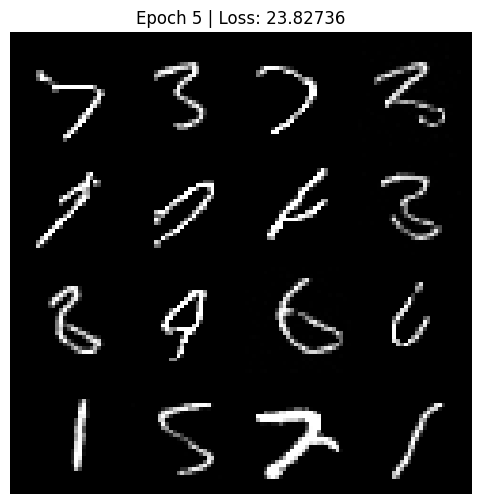

💾 Model saved to ./checkpoints/ncsn_epoch_5.pth


Epoch 6/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 6 | Avg Loss: 23.57362


Epoch 7/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 7 | Avg Loss: 23.51354


...

🏁 Epoch 8 | Avg Loss: 23.53412


Epoch 9/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 9 | Avg Loss: 23.25157


Epoch 10/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 10 | Avg Loss: 23.22811
🎨 Generating samples for Epoch 10...


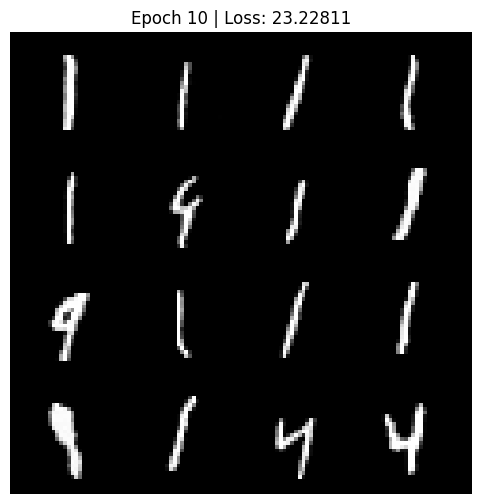

💾 Model saved to ./checkpoints/ncsn_epoch_10.pth


Epoch 11/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 11 | Avg Loss: 23.35243


Epoch 12/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 12 | Avg Loss: 23.24160


...

🏁 Epoch 13 | Avg Loss: 23.00552


Epoch 14/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 14 | Avg Loss: 22.93964


Epoch 15/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 15 | Avg Loss: 22.91848
🎨 Generating samples for Epoch 15...


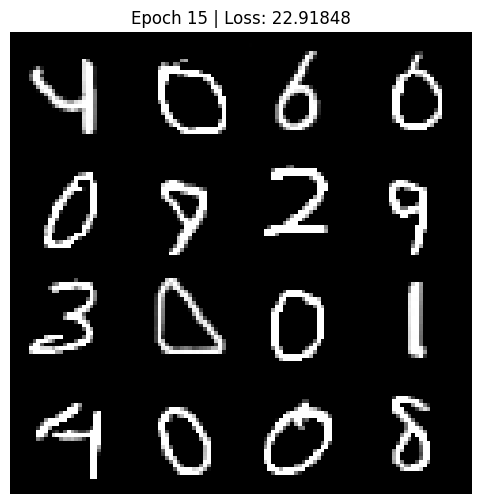

💾 Model saved to ./checkpoints/ncsn_epoch_15.pth


Epoch 16/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 16 | Avg Loss: 22.73923


Epoch 17/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 17 | Avg Loss: 22.67397


...

🏁 Epoch 18 | Avg Loss: 22.64152


Epoch 19/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 19 | Avg Loss: 22.59281


Epoch 20/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 20 | Avg Loss: 22.65190
🎨 Generating samples for Epoch 20...


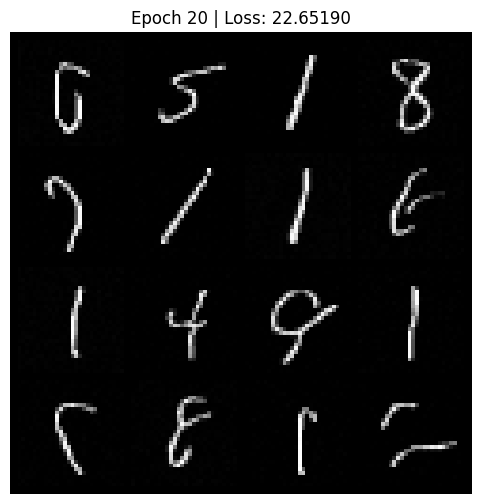

💾 Model saved to ./checkpoints/ncsn_epoch_20.pth


Epoch 21/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 21 | Avg Loss: 22.58815


Epoch 22/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 22 | Avg Loss: 22.35969


...

🏁 Epoch 23 | Avg Loss: 22.29758


Epoch 24/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 24 | Avg Loss: 22.33369


Epoch 25/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 25 | Avg Loss: 22.47353
🎨 Generating samples for Epoch 25...


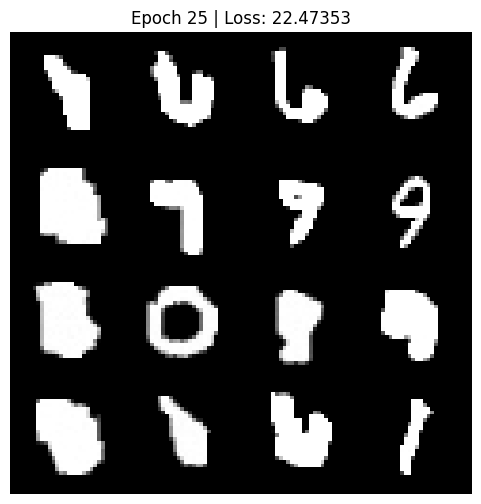

💾 Model saved to ./checkpoints/ncsn_epoch_25.pth


Epoch 26/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 26 | Avg Loss: 22.38447


Epoch 27/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 27 | Avg Loss: 22.35334


...

🏁 Epoch 28 | Avg Loss: 22.11108


Epoch 29/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 29 | Avg Loss: 22.21386


Epoch 30/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 30 | Avg Loss: 22.25132
🎨 Generating samples for Epoch 30...


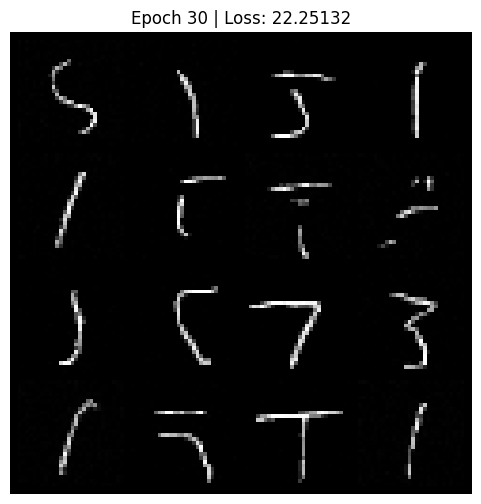

💾 Model saved to ./checkpoints/ncsn_epoch_30.pth


Epoch 31/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 31 | Avg Loss: 22.19949


Epoch 32/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 32 | Avg Loss: 22.12010


...

🏁 Epoch 33 | Avg Loss: 22.20662


Epoch 34/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 34 | Avg Loss: 22.06525


Epoch 35/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 35 | Avg Loss: 22.04882
🎨 Generating samples for Epoch 35...


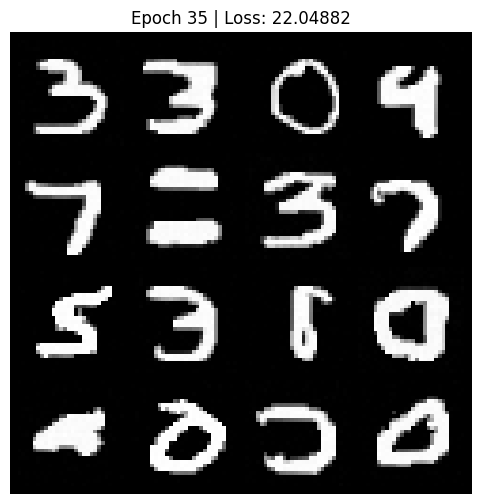

💾 Model saved to ./checkpoints/ncsn_epoch_35.pth


Epoch 36/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 36 | Avg Loss: 22.14144


Epoch 37/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 37 | Avg Loss: 21.95974


...

🏁 Epoch 38 | Avg Loss: 21.87467


Epoch 39/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 39 | Avg Loss: 21.97642


Epoch 40/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 40 | Avg Loss: 21.80873
🎨 Generating samples for Epoch 40...


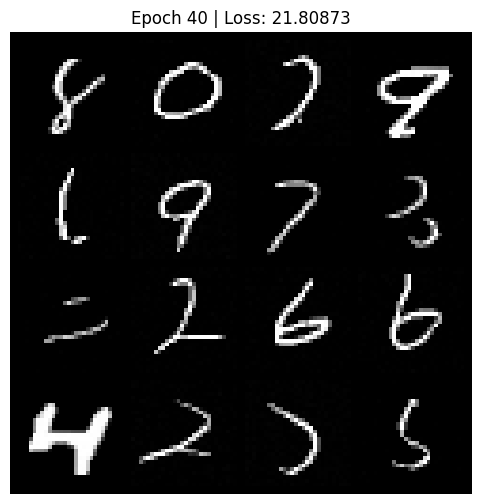

💾 Model saved to ./checkpoints/ncsn_epoch_40.pth


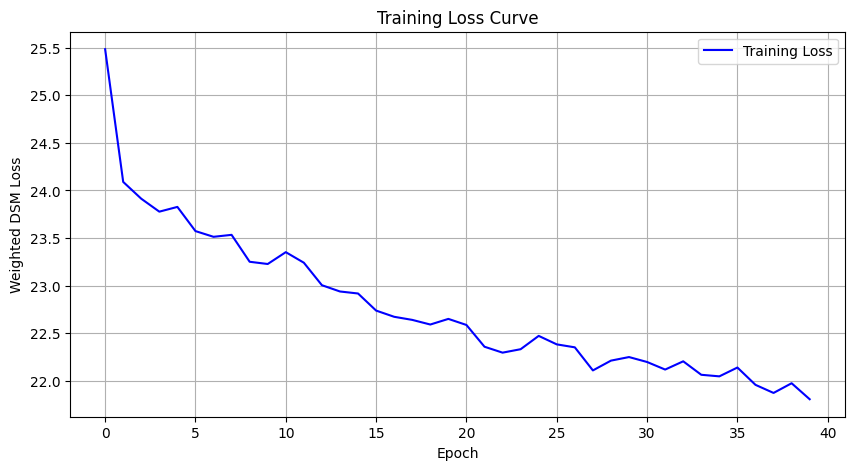

✅ Training Finished!


In [16]:
import torch.optim as optim
from tqdm.notebook import tqdm
import os

# ==========================================
# 4. Main Training Loop
# ==========================================

# Initialize Optimizer
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

loss_history = []
print(f"🚀 Starting Training for {config.epochs} epochs...")

# Create directory for checkpoints if it doesn't exist
os.makedirs(config.save_dir, exist_ok=True)

for epoch in range(config.epochs):
    model.train()
    running_loss = 0.0

    # Progress bar for the current epoch
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs}", leave=False)

    for x, _ in pbar:
        x = x.to(config.device)
        batch_size = x.shape[0]

        # 1. Sample random noise levels for each image in the batch
        # We pick random indices from [0, num_classes-1]
        indices = torch.randint(0, config.num_classes, (batch_size,), device=config.device)
        used_sigmas = sigmas[indices]

        # 2. Perturb data with noise (x_tilde = x + sigma * z)
        z = torch.randn_like(x)
        sigma_x = used_sigmas.view(batch_size, 1, 1, 1) # Reshape for broadcasting
        x_tilde = x + sigma_x * z

        # 3. Predict Score
        # The model returns: s_theta(x_tilde, sigma)
        score = model(x_tilde, used_sigmas)

        # 4. Calculate Loss
        # Target: The score should approximate -z/sigma.
        # Since our model output is already divided by sigma (in the architecture),
        # we multiply by sigma to bring it to the scale of 'z'.
        # Objective: Minimize || score * sigma + z ||^2
        target = -z
        loss = 0.5 * ((score * sigma_x - target) ** 2).sum() / batch_size

        # 5. Optimization Step
        optimizer.zero_grad()
        loss.backward()

        # Gradient Clipping: Prevents gradients from exploding (crucial for score models)
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)

        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    # End of Epoch Stats
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(f"🏁 Epoch {epoch+1} | Avg Loss: {epoch_loss:.5f}")

    # Visualization & Checkpointing
    if (epoch + 1) % config.vis_freq == 0 or (epoch + 1) == config.epochs:
        print(f"🎨 Generating samples for Epoch {epoch+1}...")

        # Generate samples using the fixed noise
        samples = generate_samples_during_training(model, sigmas, config)
        plot_grid(samples, epoch+1, epoch_loss)

        # Save Model Checkpoint
        ckpt_path = os.path.join(config.save_dir, f"ncsn_epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), ckpt_path)
        print(f"💾 Model saved to {ckpt_path}")

# Plot Final Training Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Weighted DSM Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.legend()
plt.show()

print("✅ Training Finished!")

Generating Visualization...


Denoising Process:   0%|          | 0/50 [00:00<?, ?it/s]

Plotting steps: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]


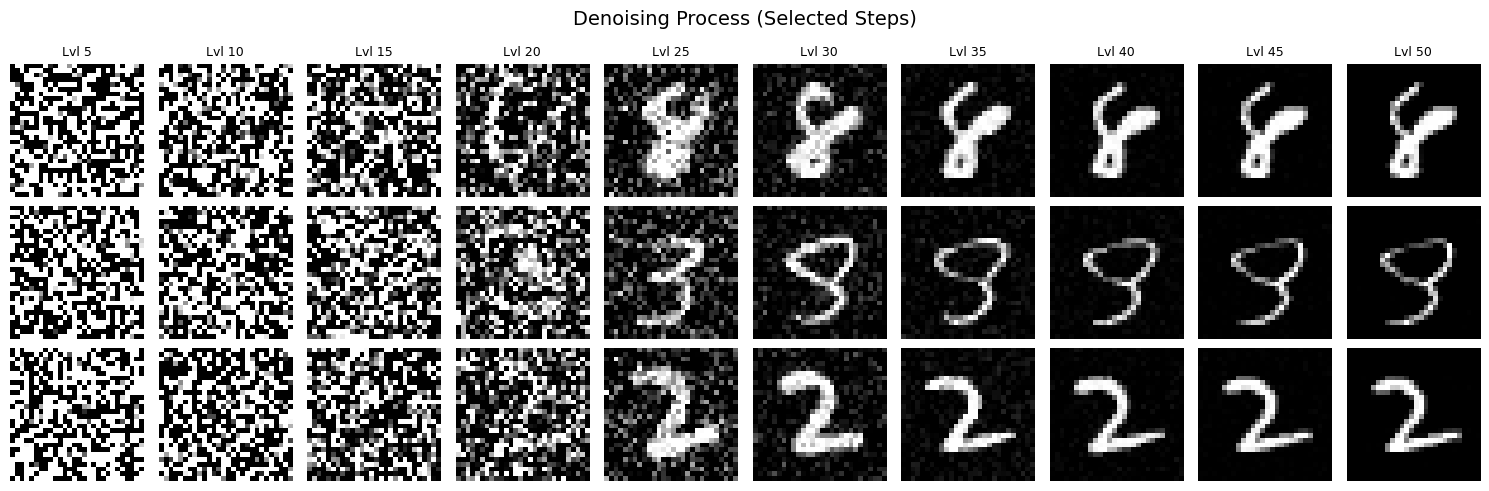

In [19]:
def visualize_denoising_process(model, sigmas, config):
    """
    Performs sampling and visualizes a subset of steps (e.g., every 5th step)
    to keep the plot readable.
    """
    model.eval()
    n_vis = 3 # Number of rows

    # Start with random noise
    x = torch.randn(n_vis, 1, 28, 28, device=config.device)

    history = []

    with torch.no_grad():
        progress_bar = tqdm(enumerate(sigmas), total=len(sigmas), desc="Denoising Process")

        for i, sigma in progress_bar:
            sigma_val = sigma.item()
            sigma_L = sigmas[-1].item()
            alpha = config.step_lr * (sigma_val / sigma_L) ** 2

            for t in range(config.sampling_steps):
                z = torch.randn_like(x)
                sigma_expanded = torch.ones(n_vis, device=config.device) * sigma

                # If using conditional model, pass labels here. Otherwise:
                score = model(x, sigma_expanded)

                noise_term = torch.sqrt(torch.tensor(alpha)) * z
                score_term = (alpha / 2) * score
                x = x + score_term + noise_term

            # Save snapshot
            history.append(x.cpu().clone())

    # --- Plotting Selection Logic ---
    total_steps = len(history)

    # [CHANGED] Select specific indices to plot
    # We want indices 0, 4, 9, 14, ... (representing levels 1, 5, 10, 15...)
    # Or simply every 5th step:
    step_interval = 5
    indices_to_plot = list(range(step_interval - 1, total_steps, step_interval))

    # Ensure the very last step is always included if it wasn't picked
    if (total_steps - 1) not in indices_to_plot:
        indices_to_plot.append(total_steps - 1)

    print(f"Plotting steps: {[i+1 for i in indices_to_plot]}") # Print levels being shown

    num_cols = len(indices_to_plot)
    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Denoising Process (Selected Steps)", fontsize=14)

    for row in range(n_vis):
        for col_idx, history_idx in enumerate(indices_to_plot):
            plt.subplot(n_vis, num_cols, row * num_cols + col_idx + 1)

            # Get the image from history at the selected index
            img_tensor = history[history_idx][row]

            # Denormalize
            img = (img_tensor.clamp(-1, 1) + 1) / 2.0

            plt.imshow(img.squeeze(), cmap='gray')
            plt.axis('off')

            # Add labels only for the first row
            if row == 0:
                plt.title(f"Lvl {history_idx+1}", fontsize=9)

    plt.tight_layout()
    plt.show()

# Run
print("Generating Visualization...")
visualize_denoising_process(model, sigmas, config)

## Q1-part2-subdivision2
---

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ==========================================
# Layer Modules (Unchanged)
# ==========================================

class GaussianFourierEmbedding(nn.Module):
    """
    Embeds scalar noise levels (sigma) into high-dimensional vectors
    using random Gaussian Fourier features.
    """
    def __init__(self, embed_dim=256, scale=30.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class FiLMLayer(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM) Layer.
    Modulates the feature map based on the conditioning embedding.
    """
    def __init__(self, in_channels, emb_dim):
        super().__init__()
        self.group_norm = nn.GroupNorm(num_groups=32, num_channels=in_channels)
        self.proj = nn.Linear(emb_dim, in_channels * 2)

    def forward(self, x, emb):
        stats = self.proj(emb)
        stats = stats[:, :, None, None]
        scale, shift = stats.chunk(2, dim=1)

        x = self.group_norm(x)
        x = x * (1 + scale) + shift
        return x


class FiLMResBlock(nn.Module):
    """
    Residual Block enhanced with FiLM layers.
    """
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.film1 = FiLMLayer(out_channels, emb_dim)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.film2 = FiLMLayer(out_channels, emb_dim)

        self.activation = nn.SiLU()

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.film1(h, emb)
        h = self.activation(h)

        h = self.conv2(h)
        h = self.film2(h, emb)
        h = self.activation(h)

        return h + self.shortcut(x)


# ==========================================
# Main Model: Conditional NCSN
# ==========================================

class ConditionalNCSN(nn.Module):
    """
    Class-Conditional Noise Conditional Score Network.
    Predicts the score based on noise level AND class label.
    """
    def __init__(self, config=None):
        super().__init__()

        # Hyperparameters
        emb_dim = 256
        num_classes = 10 # MNIST has 10 classes (0-9)

        # 1. Conditioning Heads

        # A) Noise Embedding Head (Maps sigma to vector)
        self.noise_embedding = nn.Sequential(
            GaussianFourierEmbedding(embed_dim=emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )

        # B) Class Embedding Head (Maps label y to vector) -- [NEW]
        self.class_embedding = nn.Embedding(num_classes, emb_dim)

        # 2. Input Projection
        self.input_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)

        # 3. Encoder Path
        self.down_block1 = FiLMResBlock(64, 64, emb_dim)
        self.pool1 = nn.AvgPool2d(2)

        self.down_block2 = FiLMResBlock(64, 128, emb_dim)
        self.pool2 = nn.AvgPool2d(2)

        self.bottleneck_block = FiLMResBlock(128, 256, emb_dim)

        # 4. Decoder Path
        self.up_block1 = FiLMResBlock(256 + 128, 128, emb_dim)
        self.up_block2 = FiLMResBlock(128 + 64, 64, emb_dim)

        # 5. Output Projection
        self.output_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x, sigma, y):
        """
        Args:
            x: Input images [Batch, 1, 28, 28]
            sigma: Noise levels [Batch]
            y: Class labels [Batch] -- [NEW]
        """
        # Get Embeddings
        sigma_emb = self.noise_embedding(sigma) # Shape: [B, 256]
        class_emb = self.class_embedding(y)     # Shape: [B, 256] -- [NEW]

        # Combine Conditions: Element-wise addition -- [NEW]
        # The network now receives both noise info and class info combined.
        total_emb = sigma_emb + class_emb

        # --- Encoder ---
        h = self.input_conv(x)

        # Layer 1
        h1 = self.down_block1(h, total_emb)
        h1_down = self.pool1(h1)

        # Layer 2
        h2 = self.down_block2(h1_down, total_emb)
        h2_down = self.pool2(h2)

        # Layer 3 (Bottleneck)
        h3 = self.bottleneck_block(h2_down, total_emb)

        # --- Decoder ---

        # Up 1
        h_up1 = F.interpolate(h3, scale_factor=2, mode='nearest')
        h_cat1 = torch.cat([h_up1, h2], dim=1)
        h4 = self.up_block1(h_cat1, total_emb)

        # Up 2
        h_up2 = F.interpolate(h4, scale_factor=2, mode='nearest')
        h_cat2 = torch.cat([h_up2, h1], dim=1)
        h5 = self.up_block2(h_cat2, total_emb)

        # --- Output Head ---
        out = self.output_conv(h5)

        # Normalize output by sigma
        out = out / sigma[:, None, None, None]

        return out

# Instantiate conditional model
model = ConditionalNCSN().to(config.device)
print("\n--- Conditional NCSN Model Initialized ---")
print(model)


--- Conditional NCSN Model Initialized ---
ConditionalNCSN(
  (noise_embedding): Sequential(
    (0): GaussianFourierEmbedding()
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (class_embedding): Embedding(10, 256)
  (input_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_block1): FiLMResBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (film1): FiLMLayer(
      (group_norm): GroupNorm(32, 64, eps=1e-05, affine=True)
      (proj): Linear(in_features=256, out_features=128, bias=True)
    )
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (film2): FiLMLayer(
      (group_norm): GroupNorm(32, 64, eps=1e-05, affine=True)
      (proj): Linear(in_features=256, out_features=128, bias=True)
    )
    (activation): SiLU()
    (shortcut): Identity()
  )
  (pool1): AvgPool2d(kernel_size=2, stride

🚀 Starting Conditional Training for 40 epochs...


Epoch 1/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 1 | Avg Loss: 49.43709


Epoch 2/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 2 | Avg Loss: 28.84928


...

🏁 Epoch 3 | Avg Loss: 26.49493


Epoch 4/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 4 | Avg Loss: 25.45600


Epoch 5/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 5 | Avg Loss: 24.99007
🎨 Generating random conditional samples for Epoch 5...


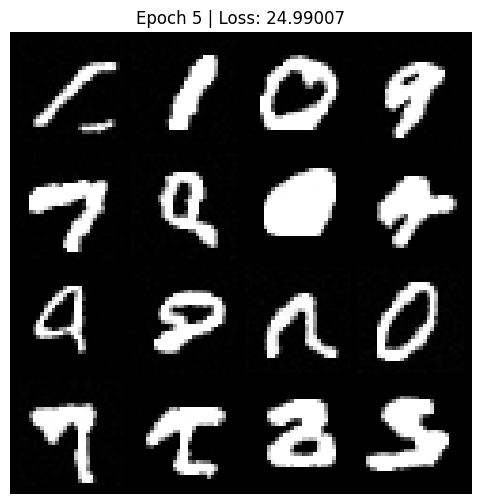

💾 Model saved to ./checkpoints/conditional_ncsn_epoch_5.pth


Epoch 6/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 6 | Avg Loss: 24.49008


Epoch 7/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 7 | Avg Loss: 24.39663


...

🏁 Epoch 8 | Avg Loss: 24.21271


Epoch 9/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 9 | Avg Loss: 23.76339


Epoch 10/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 10 | Avg Loss: 23.82189
🎨 Generating random conditional samples for Epoch 10...


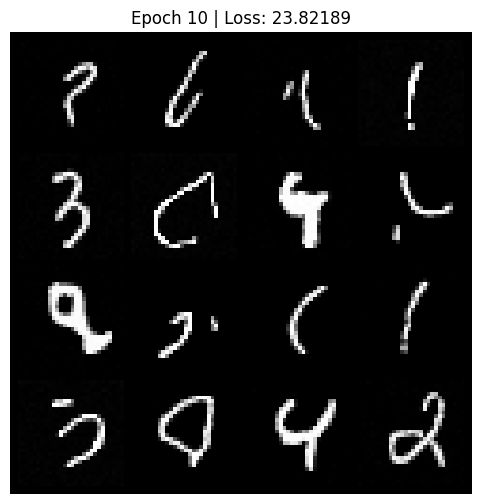

💾 Model saved to ./checkpoints/conditional_ncsn_epoch_10.pth


Epoch 11/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 11 | Avg Loss: 23.66536


Epoch 12/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 12 | Avg Loss: 23.64378


...

🏁 Epoch 13 | Avg Loss: 23.32889


Epoch 14/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 14 | Avg Loss: 23.16017


Epoch 15/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 15 | Avg Loss: 23.09657
🎨 Generating random conditional samples for Epoch 15...


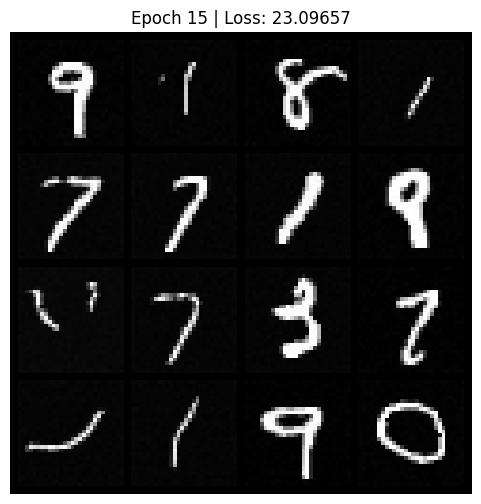

💾 Model saved to ./checkpoints/conditional_ncsn_epoch_15.pth


Epoch 16/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 16 | Avg Loss: 23.09068


Epoch 17/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 17 | Avg Loss: 22.95027


...

🏁 Epoch 18 | Avg Loss: 22.87359


Epoch 19/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 19 | Avg Loss: 22.88965


Epoch 20/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 20 | Avg Loss: 22.79496
🎨 Generating random conditional samples for Epoch 20...


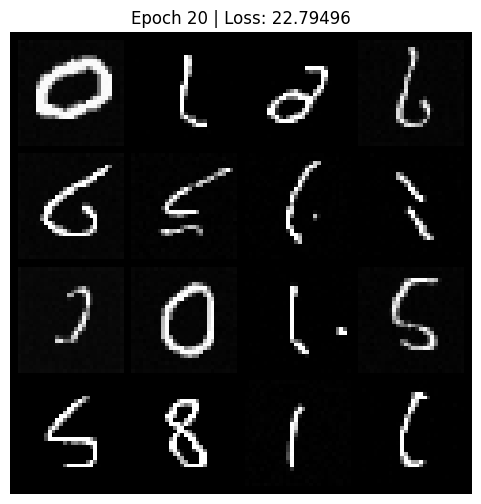

💾 Model saved to ./checkpoints/conditional_ncsn_epoch_20.pth


Epoch 21/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 21 | Avg Loss: 22.64433


Epoch 22/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 22 | Avg Loss: 22.45648


...

🏁 Epoch 23 | Avg Loss: 22.49707


Epoch 24/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 24 | Avg Loss: 22.40280


Epoch 25/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 25 | Avg Loss: 22.52751
🎨 Generating random conditional samples for Epoch 25...


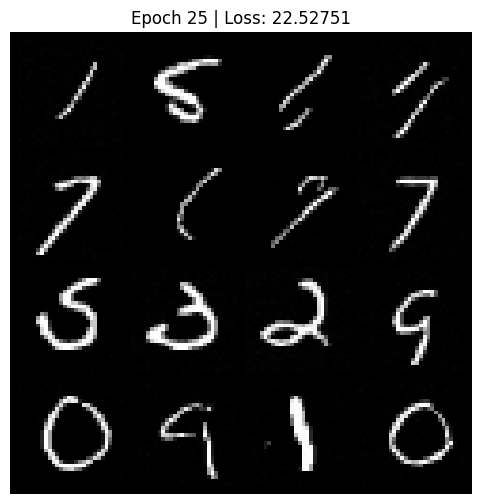

💾 Model saved to ./checkpoints/conditional_ncsn_epoch_25.pth


Epoch 26/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 26 | Avg Loss: 22.57645


Epoch 27/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 27 | Avg Loss: 22.38596


...

🏁 Epoch 28 | Avg Loss: 22.32341


Epoch 29/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 29 | Avg Loss: 22.38963


Epoch 30/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 30 | Avg Loss: 22.47186
🎨 Generating random conditional samples for Epoch 30...


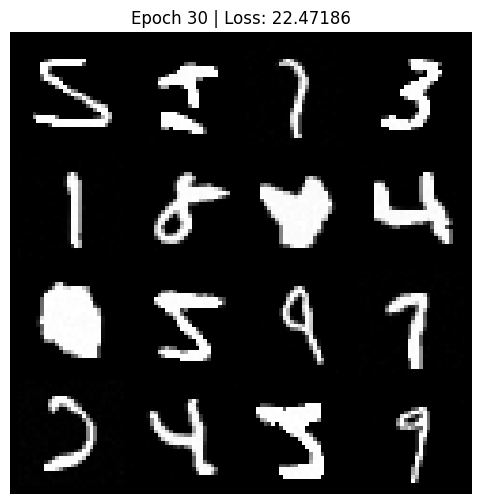

💾 Model saved to ./checkpoints/conditional_ncsn_epoch_30.pth


Epoch 31/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 31 | Avg Loss: 22.06304


Epoch 32/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 32 | Avg Loss: 22.34002


...

🏁 Epoch 33 | Avg Loss: 22.10479


Epoch 34/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 34 | Avg Loss: 22.02810


Epoch 35/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 35 | Avg Loss: 22.08449
🎨 Generating random conditional samples for Epoch 35...


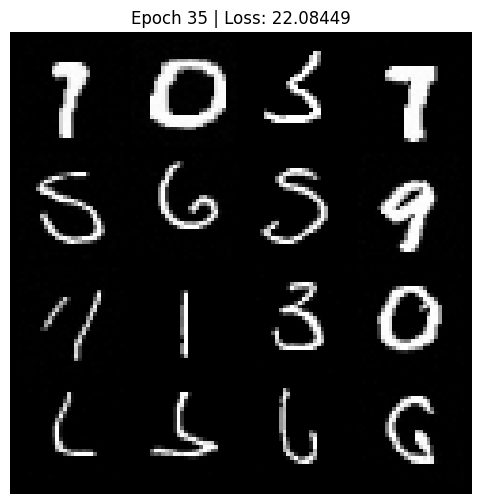

💾 Model saved to ./checkpoints/conditional_ncsn_epoch_35.pth


Epoch 36/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 36 | Avg Loss: 22.03973


Epoch 37/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 37 | Avg Loss: 21.92635


...

🏁 Epoch 38 | Avg Loss: 21.99540


Epoch 39/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 39 | Avg Loss: 21.91006


Epoch 40/40:   0%|          | 0/938 [00:00<?, ?it/s]

🏁 Epoch 40 | Avg Loss: 21.79359
🎨 Generating random conditional samples for Epoch 40...


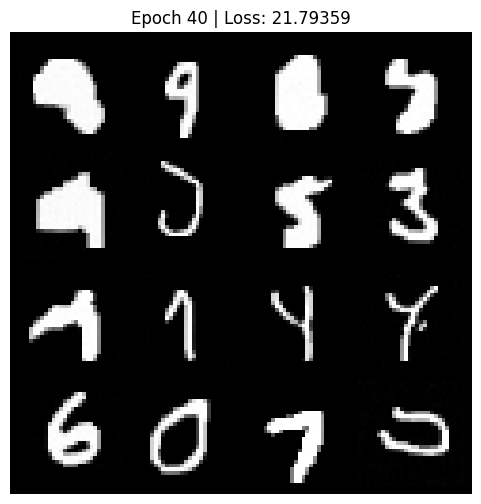

💾 Model saved to ./checkpoints/conditional_ncsn_epoch_40.pth


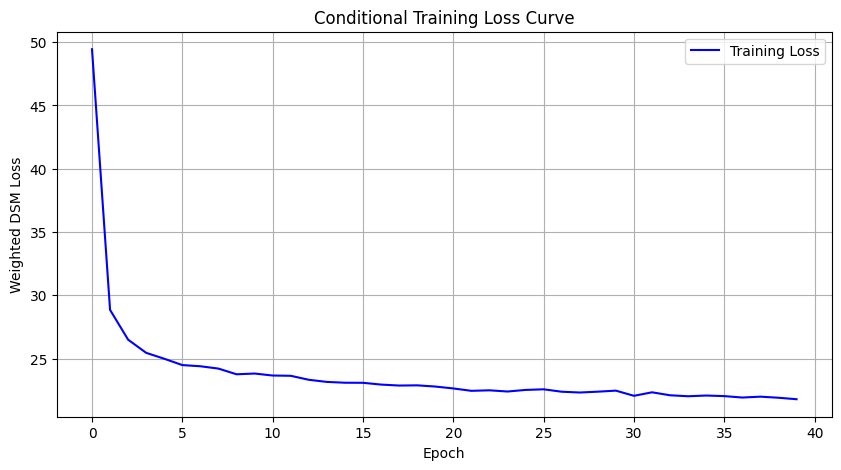

✅ Conditional Training Finished!


In [21]:
import torch.optim as optim
from tqdm.notebook import tqdm
import os
import matplotlib.pyplot as plt

# ==========================================
# Helper: Conditional Visualization during Training
# ==========================================
def generate_conditional_samples_for_vis(model, sigmas, config):
    """
    Generates samples during training for the Conditional Model.
    It generates random digits to check if the model is learning.
    """
    model.eval()

    # [NEW] Generate random class labels (0-9) for visualization
    y_vis = torch.randint(0, 10, (config.n_vis_samples,), device=config.device)

    # Start with random noise
    x = torch.randn(config.n_vis_samples, 1, 28, 28, device=config.device)

    with torch.no_grad():
        for i, sigma in enumerate(sigmas):
            sigma_val = sigma.item()
            sigma_L = sigmas[-1].item()
            alpha = config.step_lr * (sigma_val / sigma_L) ** 2

            for t in range(config.sampling_steps):
                z = torch.randn_like(x)
                sigma_expanded = torch.ones(x.shape[0], device=config.device) * sigma

                # [CHANGED] Pass labels 'y_vis' to the model
                score = model(x, sigma_expanded, y_vis)

                noise_term = torch.sqrt(torch.tensor(alpha)) * z
                score_term = (alpha / 2) * score
                x = x + score_term + noise_term

    model.train()
    return (x.clamp(-1, 1) + 1) / 2.0


# ==========================================
# 4. Main Training Loop (Conditional)
# ==========================================

# Initialize Optimizer
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

loss_history = []
print(f"🚀 Starting Conditional Training for {config.epochs} epochs...")

# Create directory for checkpoints if it doesn't exist
os.makedirs(config.save_dir, exist_ok=True)

for epoch in range(config.epochs):
    model.train()
    running_loss = 0.0

    # Progress bar for the current epoch
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs}", leave=False)

    # [CHANGED] We now unpack 'y' (labels) from the dataloader
    for x, y in pbar:
        # [CHANGED] Move both x and y to device
        x = x.to(config.device)
        y = y.to(config.device)

        batch_size = x.shape[0]

        # 1. Sample random noise levels
        indices = torch.randint(0, config.num_classes, (batch_size,), device=config.device)
        used_sigmas = sigmas[indices]

        # 2. Perturb data with noise
        z = torch.randn_like(x)
        sigma_x = used_sigmas.view(batch_size, 1, 1, 1)
        x_tilde = x + sigma_x * z

        # 3. Predict Score
        # [CHANGED] Pass class labels 'y' to the model
        score = model(x_tilde, used_sigmas, y)

        # 4. Calculate Loss
        target = -z
        loss = 0.5 * ((score * sigma_x - target) ** 2).sum() / batch_size

        # 5. Optimization Step
        optimizer.zero_grad()
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)

        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    # End of Epoch Stats
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(f"🏁 Epoch {epoch+1} | Avg Loss: {epoch_loss:.5f}")

    # Visualization & Checkpointing
    if (epoch + 1) % config.vis_freq == 0 or (epoch + 1) == config.epochs:
        print(f"🎨 Generating random conditional samples for Epoch {epoch+1}...")

        # [CHANGED] Use the new conditional visualization function
        samples = generate_conditional_samples_for_vis(model, sigmas, config)
        plot_grid(samples, epoch+1, epoch_loss)

        # Save Model Checkpoint
        ckpt_path = os.path.join(config.save_dir, f"conditional_ncsn_epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), ckpt_path)
        print(f"💾 Model saved to {ckpt_path}")

# Plot Final Training Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Weighted DSM Loss')
plt.title('Conditional Training Loss Curve')
plt.grid(True)
plt.legend()
plt.show()

print("✅ Conditional Training Finished!")

Generating 160 images (16 per digit)...


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

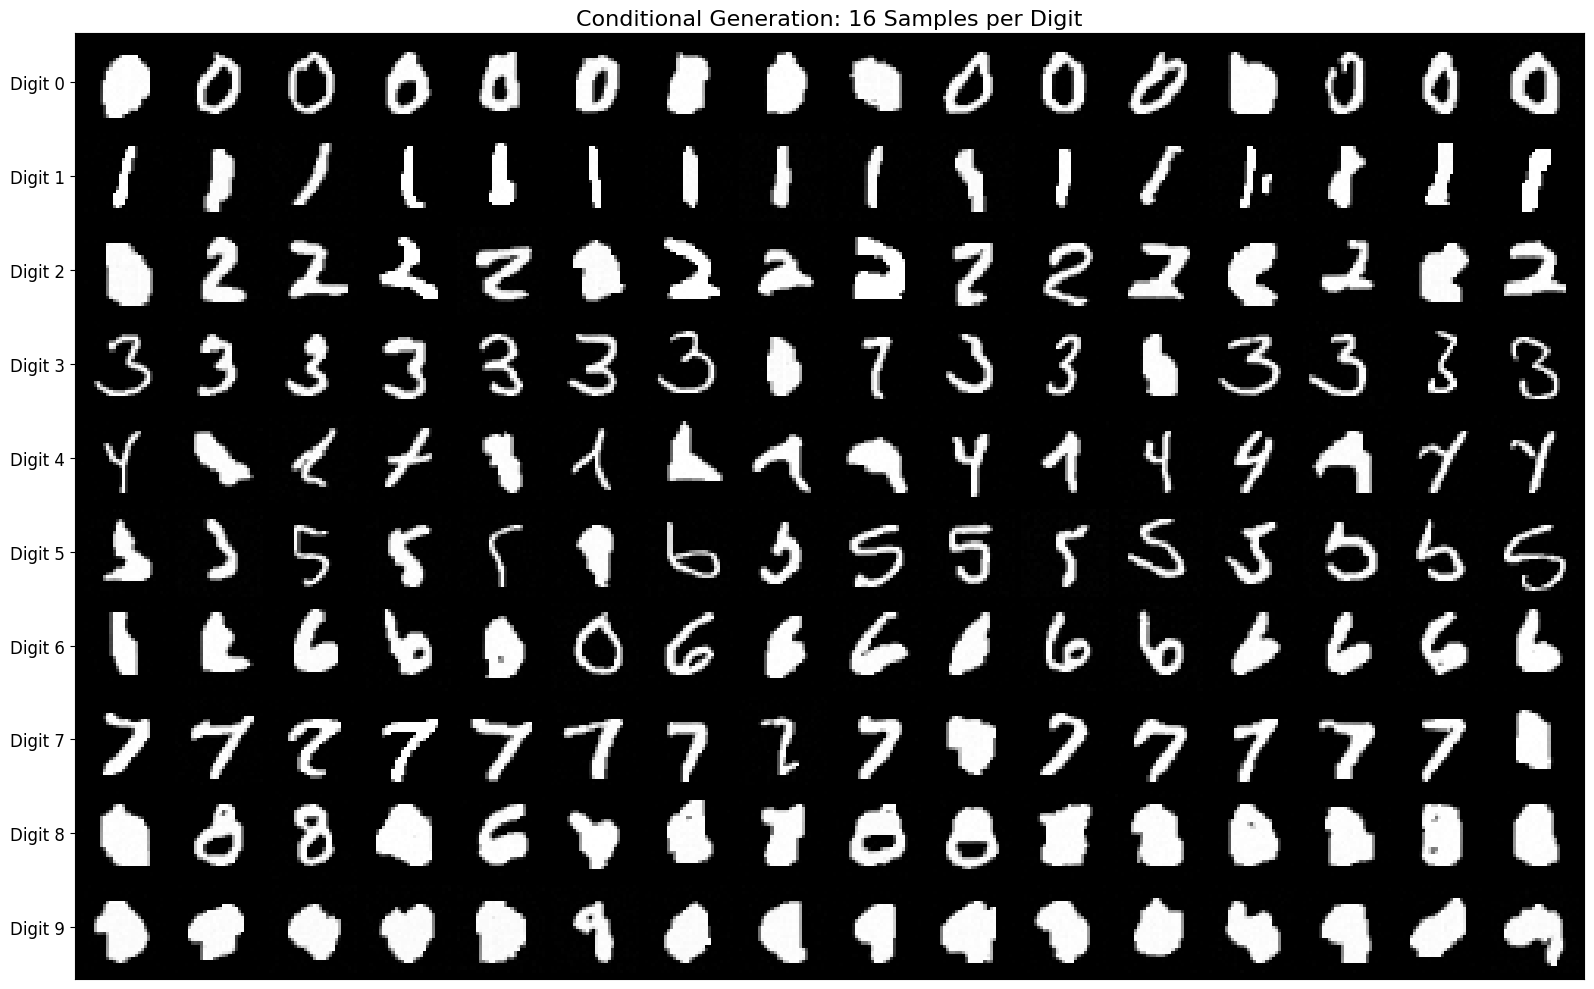

In [22]:
# ==========================================
# 6. Final Ordered Grid Generation
# ==========================================

def generate_final_ordered_grid(model, sigmas, config):
    """
    Generates a grid of images where each row corresponds to a digit (0-9).
    Row 0: Zeros, Row 1: Ones, ..., Row 9: Nines.
    """
    model.eval()

    n_classes = 10       # Digits 0 to 9
    samples_per_class = 16 # As requested (columns)
    total_samples = n_classes * samples_per_class

    # 1. Create Ordered Labels: [0,0..., 1,1..., ..., 9,9...]
    # This creates a tensor where 0 repeats 16 times, then 1, etc.
    y_labels = torch.arange(n_classes, device=config.device).repeat_interleave(samples_per_class)

    # 2. Start with Random Noise
    x = torch.randn(total_samples, 1, 28, 28, device=config.device)

    print(f"Generating {total_samples} images ({samples_per_class} per digit)...")

    with torch.no_grad():
        # Iterate through noise levels
        for i, sigma in tqdm(enumerate(sigmas), total=len(sigmas), desc="Sampling"):
            sigma_val = sigma.item()
            sigma_L = sigmas[-1].item()

            # Step size
            alpha = config.step_lr * (sigma_val / sigma_L) ** 2

            # Langevin Dynamics
            for t in range(config.sampling_steps):
                z = torch.randn_like(x)
                sigma_expanded = torch.ones(total_samples, device=config.device) * sigma

                # Condition on the ordered labels 'y_labels'
                score = model(x, sigma_expanded, y_labels)

                noise_term = torch.sqrt(torch.tensor(alpha)) * z
                score_term = (alpha / 2) * score
                x = x + score_term + noise_term

    # 3. Plotting
    # We set nrow=samples_per_class so that each row in the plot contains exactly one digit class
    grid_img = utils.make_grid(
        x,
        nrow=samples_per_class,
        padding=2,
        normalize=True,
        value_range=(-1, 1) # Normalizes from [-1, 1] to [0, 1] for display
    )

    plt.figure(figsize=(16, 10)) # Wide figure for 16 columns
    plt.imshow(grid_img.permute(1, 2, 0).cpu().numpy(), cmap='gray')

    # Add Y-axis labels for clarity
    # We calculate the approximate position of each row to place the label
    img_height = grid_img.shape[1]
    row_height = img_height // n_classes
    plt.yticks(
        ticks=np.arange(row_height//2, img_height, row_height),
        labels=[f"Digit {i}" for i in range(n_classes)],
        fontsize=12
    )
    plt.xticks([]) # Hide x-axis ticks
    plt.title("Conditional Generation: 16 Samples per Digit", fontsize=16)
    plt.tight_layout()
    plt.show()

# Run the final generation
generate_final_ordered_grid(model, sigmas, config)